In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder , StandardScaler , MinMaxScaler

from sklearn.metrics.pairwise import cosine_similarity

from tqdm import tqdm
from scipy.sparse import csr_matrix
from scipy.stats import ttest_ind, mannwhitneyu

from joblib import Parallel, delayed

import folium
from IPython.display import display
import random

Cosine similarity hesaplamak için gereken fonksiyonlar.

In [4]:
def find_most_similar_row(df, row_index, top_n=1, use_sparse=False):
    if not df.select_dtypes(include=[np.number]).columns.equals(df.columns):
        raise ValueError("Veri seti sadece sayısal sütunlar içermeli.")
    if df.isnull().any().any():
        raise ValueError("Veri setinde eksik değerler var, lütfen temizleyin.")

    data_matrix = csr_matrix(df.values) if use_sparse else df.values

    similarity_scores = cosine_similarity([data_matrix[row_index]], data_matrix)[0]
    similarity_scores[row_index] = -1  # Kendisi

    top_indices = similarity_scores.argsort()[-top_n:][::-1]
    top_scores = similarity_scores[top_indices]

    return {
        "reference_index": row_index,
        "most_similar_indices": top_indices.tolist(),
        "similarity_scores": top_scores.tolist()
    }


# Mevcut fonksiyonun optimize edilmiş versiyonu
def find_similar_for_all_rows_optimized(df, top_n=1, use_sparse=True, n_jobs=-1, show_progress=True, batch_size=1000):
    """
    Tüm satırların en benzer satırlarını bulur.
    
    Parametreler:
    - df: pandas DataFrame, sayısal veriler içermeli
    - top_n: Döndürülecek en benzer satır sayısı
    - scale_data: Veriyi standartlaştırmak için True/False
    - use_sparse: Sparse matrix kullanımı için True/False
    - n_jobs: Paralel işleme için çekirdek sayısı (-1: tüm çekirdekler)
    
    Dönen:
    - Liste: Her satır için referans indeks, benzer satır indeksleri ve skorlar
    """
    if not df.select_dtypes(include=[np.number]).columns.equals(df.columns):
        raise ValueError("Veri seti sadece sayısal sütunlar içermeli.")
    if df.isnull().any().any():
        raise ValueError("Veri setinde eksik değerler var, lütfen temizleyin.")
    
    # Sparse matrix kullan - bellek tasarrufu
    data_matrix = csr_matrix(df.values) if use_sparse else df.values
    
    # Similarity matrix'i tek seferde hesapla (daha hızlı)
    print("Similarity matrix hesaplanıyor...")
    similarity_matrix = cosine_similarity(data_matrix)
    np.fill_diagonal(similarity_matrix, -1)
    
    def compute_row_similarity(i):
        sim = similarity_matrix[i]
        top_indices = sim.argsort()[-top_n:][::-1]
        top_scores = sim[top_indices]
        return {
            "reference_index": i,
            "most_similar_indices": top_indices.tolist(),
            "similarity_scores": top_scores.tolist()
        }

    iterator = range(len(df))
    if show_progress:
        iterator = tqdm(iterator, desc="Benzerlikler işleniyor")

    # Paralel işleme - tüm çekirdekleri kullan
    if n_jobs == 1:
        results = [compute_row_similarity(i) for i in iterator]
    else:
        # Batch processing için
        results = Parallel(n_jobs=n_jobs, batch_size=batch_size)(
            delayed(compute_row_similarity)(i) for i in iterator)
    
    return results



def results_to_dataframe(results, df=None, extra_columns=None):
    """
    Benzerlik sonuçlarını DataFrame’e dönüştürür.
    
    Parametreler:
    - results: find_similar_for_all_rows veya find_most_similar_row çıktısı
    - df: Orijinal veri seti (ekstra sütunlar için)
    - extra_columns: DataFrame’e eklenecek sütun isimleri
    
    Dönen:
    - pandas DataFrame: Benzerlik sonuçları
    """
    rows = []
    for item in results:
        ref_idx = item["reference_index"]
        for sim_idx, score in zip(item["most_similar_indices"], item["similarity_scores"]):
            row = {
                "reference_index": ref_idx,
                "similar_index": sim_idx,
                "similarity_score": score
            }
            if df is not None and extra_columns is not None:
                for col in extra_columns:
                    row[f"reference_{col}"] = df.iloc[ref_idx][col]
                    row[f"similar_{col}"] = df.iloc[sim_idx][col]
            rows.append(row)
    
    if not rows:
        print("Uyarı: Hiçbir benzer satır bulunamadı.")
        return pd.DataFrame()
    
    return pd.DataFrame(rows)



Genel kullanım için fonksiyonlar.

In [5]:
def check_df(dataframe, head=5):
    print("##################### Shape #####################")
    print(dataframe.shape)
    print("##################### Types #####################")
    print(dataframe.dtypes)
    print("##################### NA #####################")
    print(dataframe.isnull().sum())


def grab_col_names(dataframe, cat_th=10, car_th=20):

    # cat_cols, cat_but_car
    cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"]
    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and
                   dataframe[col].dtypes != "O"]
    cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and
                   dataframe[col].dtypes == "O"]
    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    # num_cols
    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != "O"]
    num_cols = [col for col in num_cols if col not in num_but_cat]

    # print(f"Observations: {dataframe.shape[0]}")
    # print(f"Variables: {dataframe.shape[1]}")
    # print(f'cat_cols: {len(cat_cols)}')
    # print(f'num_cols: {len(num_cols)}')
    # print(f'cat_but_car: {len(cat_but_car)}')
    # print(f'num_but_cat: {len(num_but_cat)}')
    return cat_cols, num_cols, cat_but_car

Benzerliğe göre karşılaştırma için kullanılan fonksiyonlar.

In [6]:
from scipy.stats import ttest_ind, mannwhitneyu


def analyze_similarity_differences(df_numeric, data, reference_index, top_n=1000):
    """
    Referans nokta ile en benzer ve en az benzer noktalar arasındaki farkları analiz eder
    """
    # Benzer noktaları bul
    result = find_most_similar_row(df_numeric, row_index=reference_index, top_n=top_n)
    similar_indices = result['most_similar_indices']
    similarity_scores = result['similarity_scores']
    
    # En benzer %10 ve En az benzeyen X satırı alıyorum( %10 fazla oluyor)
    n_top = max(1, len(similar_indices) // 10)

    most_similar_indices = similar_indices[:n_top]
    least_similar_indices = similar_indices[-n_top:]
    
    most_similar_scores = similarity_scores[:n_top]
    least_similar_scores = similarity_scores[-n_top:]
    
    # Referans nokta verileri
    ref_data = df_numeric.iloc[reference_index]
    
    # En benzer ve en az benzer grupların verileri
    most_similar_data = df_numeric.iloc[most_similar_indices]
    least_similar_data = df_numeric.iloc[least_similar_indices]
    
    print(f"🎯 REFERANS NOKTA ANALİZİ (Index: {reference_index})")
    print(f"📊 Toplam analiz edilen nokta sayısı: {len(similar_indices)}")
    print(f"✅ En benzer {n_top} nokta - Ortalama benzerlik: {np.mean(most_similar_scores):.4f}")
    print(f"❌ En az benzer {200} nokta - Ortalama benzerlik: {np.mean(least_similar_scores):.4f}")
    print("-" * 60)
    
    return {
        'reference_index': reference_index,
        'ref_data': ref_data,
        'most_similar_data': most_similar_data,
        'least_similar_data': least_similar_data,
        'most_similar_indices': most_similar_indices,
        'least_similar_indices': least_similar_indices,
        'most_similar_scores': most_similar_scores,
        'least_similar_scores': least_similar_scores
    }

def feature_importance_analysis(analysis_result):
    """
    Hangi özellikler en çok fark yaratıyor analizi
    """
    ref_data = analysis_result['ref_data']
    most_similar_data = analysis_result['most_similar_data']
    least_similar_data = analysis_result['least_similar_data']
    
    # Her özellik için farkları hesapla
    feature_differences = {}
    
    for col in ref_data.index:
        ref_value = ref_data[col]
        
        # En benzer grup ile referans arasındaki ortalama fark
        most_similar_diff = np.mean(np.abs(most_similar_data[col] - ref_value))
        
        # Benzemeyen grup ile referans arasındaki ortalama fark
        least_similar_diff = np.mean(np.abs(least_similar_data[col] - ref_value))
        
        # Fark oranı (ne kadar ayırt edici) 
        discriminative_power = least_similar_diff - most_similar_diff
        
        feature_differences[col] = {
            'most_similar_avg_diff': most_similar_diff,
            'least_similar_avg_diff': least_similar_diff,
            'discriminative_power': discriminative_power,
            'relative_importance': discriminative_power / (least_similar_diff + 1e-8)
        }
    
    # DataFrame'e dönüştür
    feature_df = pd.DataFrame(feature_differences).T
    feature_df = feature_df.sort_values('discriminative_power', ascending=False)
    
    print("🔍 ÖZELLİK ÖNEM ANALİZİ")
    print("=" * 80)
    print("discriminative_power a göre sıralandı.")
    display(feature_df.head(10))
    
    return feature_df


# boxplot , kde-plot  , cdf-plot görselleştirmeleri için fonksiyonlar
def visualize_feature_differences(analysis_result, feature_df, top_features=8):
    """
    Özellik farklarını görselleştir
    """
    ref_data = analysis_result['ref_data']
    most_similar_data = analysis_result['most_similar_data']
    least_similar_data = analysis_result['least_similar_data']
    
    # En önemli özellikleri al
    top_cols = feature_df.head(top_features).index.tolist()
    
    # Görselleştirme
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()
    
    for i, col in enumerate(top_cols):
        ax = axes[i]
        
        # Veri hazırlama
        ref_val = ref_data[col]
        most_sim_vals = most_similar_data[col].values
        least_sim_vals = least_similar_data[col].values
        
        # Box plot
        data_to_plot = [most_sim_vals, least_sim_vals]
        labels = ['En Benzer', 'En Az Benzer']
        
        box_plot = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)
        box_plot['boxes'][0].set_facecolor('lightgreen')
        box_plot['boxes'][1].set_facecolor('lightcoral')
        
        # Referans değerini işaretle
        ax.axhline(y=ref_val, color='red', linestyle='--', linewidth=2, label=f'Referans: {ref_val:.3f}')
        
        ax.set_title(f'{col}\n(Önem: {feature_df.loc[col, "discriminative_power"]:.4f})')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.suptitle('En Ayırt Edici Özelliklerin Karşılaştırması', fontsize=16, y=1.02)
    plt.show()

def plot_feature_kde_differences(analysis_result, feature_df, top_features=8):
    """
    En önemli özellikler için iki grubun KDE (yoğunluk) dağılımlarını çizer.
    """
    import seaborn as sns
    ref_data = analysis_result['ref_data']
    most_similar_data = analysis_result['most_similar_data']
    least_similar_data = analysis_result['least_similar_data']

    top_cols = feature_df.head(top_features).index.tolist()
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    for i, col in enumerate(top_cols):
        ax = axes[i]
        sns.kdeplot(most_similar_data[col], ax=ax, label='En Benzer', fill=True, color='green', alpha=0.5)
        sns.kdeplot(least_similar_data[col], ax=ax, label='En Az Benzer', fill=True, color='red', alpha=0.5)
        ax.axvline(ref_data[col], color='blue', linestyle='--', linewidth=2, label=f'Referans: {ref_data[col]:.3f}')
        ax.set_title(f'{col}\n(Discriminative Power: {feature_df.loc[col, "discriminative_power"]:.4f})')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.suptitle('En Ayırt Edici Özelliklerin KDE Dağılımı', fontsize=16, y=1.02)
    plt.show()

def plot_feature_cdf_differences(analysis_result, feature_df, top_features=8):
    """
    En önemli özellikler için iki grubun CDF (kümülatif dağılım fonksiyonu) eğrilerini çizer.
    """
    ref_data = analysis_result['ref_data']
    most_similar_data = analysis_result['most_similar_data']
    least_similar_data = analysis_result['least_similar_data']

    top_cols = feature_df.head(top_features).index.tolist()
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    for i, col in enumerate(top_cols):
        ax = axes[i]
        # En benzer grup için CDF
        sorted_most = np.sort(most_similar_data[col])
        y_most = np.arange(1, len(sorted_most)+1) / len(sorted_most)
        ax.plot(sorted_most, y_most, label='En Benzer', color='green')

        # En az benzer grup için CDF
        sorted_least = np.sort(least_similar_data[col])
        y_least = np.arange(1, len(sorted_least)+1) / len(sorted_least)
        ax.plot(sorted_least, y_least, label='En Az Benzer', color='red')

        # Referans değeri
        ax.axvline(ref_data[col], color='blue', linestyle='--', linewidth=2, label=f'Referans: {ref_data[col]:.3f}')
        ax.set_title(f'{col}\n(Önem: {feature_df.loc[col, "discriminative_power"]:.4f})')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.suptitle('En Ayırt Edici Özelliklerin CDF Karşılaştırması', fontsize=16, y=1.02)
    plt.show()

# İstatistiksel testler ve coğrafi karşılaştırma.
def statistical_comparison(analysis_result, feature_df):
    """
    İstatistiksel karşılaştırma
    """
    most_similar_data = analysis_result['most_similar_data']
    least_similar_data = analysis_result['least_similar_data']
    
    print("\n📈 İSTATİSTİKSEL KARŞILAŞTIRMA")
    print("=" * 60)
    
    # En önemli 5 özellik için detaylı karşılaştırma
    top_5_features = feature_df.head(5).index.tolist()
    
    for feature in top_5_features:
        most_sim_vals = most_similar_data[feature]
        least_sim_vals = least_similar_data[feature]

        # t-testi ve Mann-Whitney U testi
        t_stat, t_p = ttest_ind(most_sim_vals, least_sim_vals, equal_var=False)
        u_stat, u_p = mannwhitneyu(most_sim_vals, least_sim_vals, alternative='two-sided')
        pooled_std = np.sqrt((most_sim_vals.std()**2 + least_sim_vals.std()**2) / 2)
        cohens_d = (most_sim_vals.mean() - least_sim_vals.mean()) / pooled_std
        
        
        print(f"\n🔸 {feature}:")
        print(f"   En Benzer Grup  - Ortalama: {most_sim_vals.mean():.4f}, Std: {most_sim_vals.std():.4f}")
        print(f"   En Az Benzer Grup - Ortalama: {least_sim_vals.mean():.4f}, Std: {least_sim_vals.std():.4f}")
        print(f"   Ortalama Farkı: {abs(most_sim_vals.mean() - least_sim_vals.mean()):.4f}")
        print(f"   t-testi p-değeri: {t_p:.4e} | Mann-Whitney U p-değeri: {u_p:.4e}")
        print(f"   Cohen's d: {cohens_d:.4f}")

def geographic_analysis(analysis_result, data):
    """
    Coğrafi analiz - koordinat bazında
    """
    most_similar_indices = analysis_result['most_similar_indices']
    least_similar_indices = analysis_result['least_similar_indices']
    reference_index = analysis_result['reference_index']
    
    # Koordinatları al
    ref_lat = data.loc[reference_index, 'Latitude']
    ref_lon = data.loc[reference_index, 'Longitude']
    
    most_sim_coords = data.loc[most_similar_indices, ['Latitude', 'Longitude']]
    least_sim_coords = data.loc[least_similar_indices, ['Latitude', 'Longitude']]
    
    # Mesafeleri hesapla (basit Euclidean)
    def calculate_distance(lat1, lon1, lat2, lon2):
        return np.sqrt((lat1 - lat2)**2 + (lon1 - lon2)**2)
    
    most_sim_distances = [calculate_distance(ref_lat, ref_lon, lat, lon) 
                         for lat, lon in zip(most_sim_coords['Latitude'], most_sim_coords['Longitude'])]
    
    least_sim_distances = [calculate_distance(ref_lat, ref_lon, lat, lon) 
                          for lat, lon in zip(least_sim_coords['Latitude'], least_sim_coords['Longitude'])]
    
    print(f"\n🗺️ COĞRAFİ ANALİZ")
    print("=" * 40)
    print(f"En benzer noktaların ortalama mesafesi: {np.mean(most_sim_distances):.6f}")
    print(f"En az benzer noktaların ortalama mesafesi: {np.mean(least_sim_distances):.6f}")
    
    # Coğrafi dağılım korelasyonu
    if np.mean(most_sim_distances) < np.mean(least_sim_distances):
        print("✅ Yakın noktalar daha benzer görünüyor (coğrafi korelasyon var)")
    else:
        print("❌ Mesafe ile benzerlik arasında ters korelasyon var")

In [8]:
data = pd.read_csv(r"C:\Users\Abdulkadir\Desktop\proje\5g_cosine_sim\5G_DataSet.csv")

df = data.copy()
display(df.head())

,Unnamed: 0,Time,DL_NR_UE_RSRP_0,DL_NR_UE_RSRQ_0,DL_NR_UE_SINR_0,DL_NR_UE_Nbr_RSRP_0,DL_NR_UE_Nbr_RSRP_1,DL_NR_UE_Nbr_RSRP_2,DL_NR_UE_Nbr_RSRP_3,DL_NR_UE_Nbr_RSRP_4,...,DL_NR_UE_Modulation_Avg_DL_0_64QAM,DL_NR_UE_Modulation_Avg_DL_0_QPSK,UL_NR_UE_Modulation_Avg_DL_0_16QAM,UL_NR_UE_Modulation_Avg_DL_0_256QAM,UL_NR_UE_Modulation_Avg_DL_0_64QAM,UL_NR_UE_Modulation_Avg_DL_0_QPSK,x,y,DL_Distance,UL_Distance
0,0,2025-03-14 12:14:32.955,-87.1,-11.2,7.3,-97.3,-88.6,-99.1,-120.6,-116.8,...,False,False,False,True,False,False,2.434919e+06,4.576057e+06,705.394316,396.672374
1,1,2025-03-14 12:14:32.966,-87.1,-11.2,7.3,-97.3,-88.6,-99.1,-120.6,-116.8,...,False,False,False,True,False,False,2.434919e+06,4.576057e+06,705.394316,396.672374
2,3,2025-03-14 12:14:33.135,-87.1,-11.2,7.3,-97.3,-88.6,-99.1,-120.6,-116.8,...,False,False,False,True,False,False,2.434919e+06,4.576057e+06,705.394316,396.672374
3,4,2025-03-14 12:14:33.444,-87.1,-11.2,7.3,-97.3,-88.6,-99.1,-120.6,-116.8,...,False,False,False,True,False,False,2.434919e+06,4.576057e+06,705.394316,396.672374
4,5,2025-03-14 12:14:33.499,-87.1,-11.2,7.3,-97.3,-88.6,-99.1,-120.6,-116.8,...,False,False,False,True,False,False,2.434919e+06,4.576057e+06,705.394316,396.672374


Zaan özelliğini ayarlama , enlem boylam bilgisini çıkarma. Kategorik özellikleri kodlama , Ölçeklendirme.

In [9]:
df['Time'] = pd.to_datetime(df['Time'])
df['Time_Seconds'] = (df['Time'] - df['Time'].min()).dt.total_seconds()


# Remve long , lat , unnamed columns 

df = df.drop(columns=['Unnamed: 0', 'Latitude', 'Longitude'])

# Convert categorical columns to numerical using Label Encoding

categorical_cols = df.select_dtypes(include=['object']).columns

le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le


# Scale numerical columns using MinMaxScaler
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
scaler = MinMaxScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [10]:
df_numeric = df.select_dtypes(include=['float64', 'int64'])

# Remove columns with low variance
df_numeric = df_numeric.loc[:, df_numeric.std() > 0.1]
df_numeric = df_numeric.drop_duplicates()
# Check the shape after preprocessing
print(f"Shape after preprocessing: {df_numeric.shape}")
print("\nTekrar eden satır sayısı:", df_numeric.duplicated().sum())

display(df_numeric.head())

Shape after preprocessing: (21049, 74)

Tekrar eden satır sayısı: 0


,DL_NR_UE_RSRP_0,DL_NR_UE_RSRQ_0,DL_NR_UE_SINR_0,DL_NR_UE_Nbr_RSRP_0,DL_NR_UE_Nbr_RSRP_1,DL_NR_UE_Nbr_RSRP_2,DL_NR_UE_Nbr_RSRP_3,DL_NR_UE_Nbr_RSRP_4,DL_NR_UE_Nbr_RSRQ_0,DL_NR_UE_Nbr_RSRQ_1,...,SC_NR_Scan_SSB_SINR_SortedBy_RSRP_2,SC_NR_Scan_SSB_SINR_SortedBy_RSRP_3,SC_NR_Scan_SSB_SINR_SortedBy_RSRP_4,SC_NR_Scan_SSB_SINR_SortedBy_RSRP_5,SC_NR_Scan_SSB_SINR_SortedBy_RSRP_6,x,y,DL_Distance,UL_Distance,Time_Seconds
0,0.636273,0.967033,0.434932,0.587174,0.741573,0.758772,0.84434,1.0,0.816514,0.90678,...,0.425606,0.511075,0.352453,0.337648,0.353193,0.731563,0.906522,0.001342,0.000684,0.000000
1,0.636273,0.967033,0.434932,0.587174,0.741573,0.758772,0.84434,1.0,0.816514,0.90678,...,0.425606,0.511075,0.352453,0.337648,0.353193,0.731563,0.906522,0.001342,0.000684,0.000010
2,0.636273,0.967033,0.434932,0.587174,0.741573,0.758772,0.84434,1.0,0.816514,0.90678,...,0.425606,0.511075,0.352453,0.337648,0.353193,0.731563,0.906522,0.001342,0.000684,0.000169
3,0.636273,0.967033,0.434932,0.587174,0.741573,0.758772,0.84434,1.0,0.816514,0.90678,...,0.425606,0.511075,0.352453,0.337648,0.353193,0.731563,0.906522,0.001342,0.000684,0.000459
4,0.636273,0.967033,0.434932,0.587174,0.741573,0.758772,0.84434,1.0,0.816514,0.90678,...,0.425606,0.511075,0.352453,0.337648,0.353193,0.731563,0.906522,0.001342,0.000684,0.000511


Rastgele seçilen bir satır için benzerlik hesaplama.

In [14]:
total_rows = len(df_numeric)


random_row_index = random.randint(0, total_rows - 1)

 
result = pd.DataFrame(find_most_similar_row(df_numeric, row_index=random_row_index, top_n=800))

display(result)
print(f"Seçilen indeks: {random_row_index}")

# Özet
print("="*50)
print("Similarity Score özet:")
display(result["similarity_scores"].describe())

,reference_index,most_similar_indices,similarity_scores
0,13384,13385,1.000000
1,13384,13382,0.996218
2,13384,13383,0.996217
3,13384,13381,0.996131
4,13384,13380,0.996130
...,...,...,...
795,13384,6859,0.903595
796,13384,13640,0.903578
797,13384,13641,0.903524
798,13384,6787,0.903517


Seçilen indeks: 13384
Similarity Score özet:


count    800.000000
mean       0.922326
std        0.022939
min        0.903499
25%        0.906265
50%        0.910473
75%        0.936027
max        1.000000
Name: similarity_scores, dtype: float64

tüm satırlar için benzerlik hesaplama.

In [15]:
results = find_similar_for_all_rows_optimized(
    df_numeric, 
    top_n=1,           
    use_sparse=True,   
    n_jobs=-1,         
    show_progress=True,
    batch_size=2000    
)

Similarity matrix hesaplanıyor...


Benzerlikler işleniyor: 100%|██████████| 21049/21049 [00:04<00:00, 4908.52it/s]


In [16]:
results_df = results_to_dataframe(results)
display(results_df.head(10))

,reference_index,similar_index,similarity_score
0,0,1,1.0
1,1,0,1.0
2,2,1,1.0
3,3,4,1.0
4,4,3,1.0
5,5,6,1.0
6,6,5,1.0
7,7,6,1.0
8,8,7,1.0
9,9,10,1.0


Harita Üzerinde inceleme

Rastgele bir kayıt referans seçiliyor.Referansa en benzer satırlar sıralanıyor ve bu sıraya göre renklendirme yapılıyor.

In [17]:
total_rows = len(data)
random_row_index = random.randint(0, total_rows - 1)

result = pd.DataFrame(find_most_similar_row(df_numeric, row_index=random_row_index, top_n=30000))

# Koordinatları ve skorları al
similar_indices = result['most_similar_indices'].tolist()
similarity_scores = result['similarity_scores'].tolist()

# Referans noktasının koordinatlarını al
ref_latitude = data.loc[random_row_index, 'Latitude']
ref_longitude = data.loc[random_row_index, 'Longitude']

# Koordinatları al -> Sonrasında aynı koordinatlardan alınan kayıtları tekilleştiriyorum.
longitudes = data.loc[similar_indices, 'Longitude']
latitudes = data.loc[similar_indices, 'Latitude']

coords_df = pd.DataFrame({
    'Longitude': longitudes,
    'Latitude': latitudes,
    'Index': similar_indices,
    'Similarity_Score': similarity_scores
})# her koordinattan bir tane alınıyor.
coords_df = coords_df.drop_duplicates(subset=['Longitude', 'Latitude'], keep='first') 

# Filtrelenmiş koordinatları ve skorları al
filtered_indices = coords_df['Index'].tolist()
filtered_scores = coords_df['Similarity_Score'].tolist()
filtered_longitudes = coords_df['Longitude'].tolist()
filtered_latitudes = coords_df['Latitude'].tolist()


# ===== HARİTA OLUŞTURMA =====
# Koordinatları liste olarak al
coords = list(zip(filtered_latitudes, filtered_longitudes))

# Eğer hiç farklı koordinat yoksa uyarı ver
if len(coords) < 2:
    print("Tüm koordinatlar aynı, farklı koordinat bulunamadı!")
else:
    # Haritayı oluştur (referans noktasını merkez al)
    m = folium.Map(location=[ref_latitude, ref_longitude], zoom_start=15 , max_zoom=18) # daha fazla yakınlaştırma için max_zoom ekledim
    # m.add_child(folium.LatLngPopup())  # Tıklanabilir koordinat gösterimi için

    # Önce referans noktasını ekle (daha görünür)
    folium.Marker(
        location=[ref_latitude, ref_longitude],
        popup=f"REFERANS NOKTA - Index: {random_row_index}",
        tooltip="Referans Nokta",
        icon=folium.Icon(color='red', icon='star', prefix='fa')
    ).add_to(m)
    
    # Referans noktası için büyük bir daire de ekle
    folium.CircleMarker(
        location=[ref_latitude, ref_longitude],
        radius=5,
        color='red',
        fill=True,
        fill_color='red',
        fill_opacity=0.8,
        weight=4,
        popup=f"REFERANS NOKTA -> Index: {random_row_index}"
    ).add_to(m)

    # Benzer noktaları ekle (sıralamaya göre renklendir)
    n_points = len(coords)
    for i, ((lat, lon), score, idx) in enumerate(zip(coords, filtered_scores, filtered_indices)):
        color_value = i / (n_points - 1)
        color = f'hsl({int(240 * (1 - color_value))}, 100%, 50%)'
        folium.CircleMarker(
            location=[lat, lon],
            radius=5,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.6,
            popup=f"Similarity Score: {score:.6f}, Sıra: {i+1}, Index: {idx}"
        ).add_to(m)

    
    print(f"Rastgele seçilen referans indeks: {random_row_index}")
    print(f"{len(coords)} nokta sıralandı.\nReferans nokta KIRMIZI YILDIZ ile işaretli.")
    print("En fazla benzer kayıtlar mavi, en az benzeyenler kırmızı olacak şekilde")
    display(m)

Rastgele seçilen referans indeks: 13745
1974 nokta sıralandı.
Referans nokta KIRMIZI YILDIZ ile işaretli.
En fazla benzer kayıtlar mavi, en az benzeyenler kırmızı olacak şekilde


Harita üzerinde en yüksek benzerlik mavi en az benzerlik kırmızı gözüküyor. 


En çok benzeyen ve en az benzeyen %10 luk veri inceleniyor.

🎯 REFERANS NOKTA ANALİZİ (Index: 13745)
📊 Toplam analiz edilen nokta sayısı: 21049
✅ En benzer 2104 nokta - Ortalama benzerlik: 0.8863
❌ En az benzer 200 nokta - Ortalama benzerlik: 0.7181
------------------------------------------------------------
🔍 ÖZELLİK ÖNEM ANALİZİ
discriminative_power a göre sıralandı.


,most_similar_avg_diff,least_similar_avg_diff,discriminative_power,relative_importance
UL_NR_UE_Throughput_RLC_UL,0.154532,0.731230,0.576698,0.788668
UL_NR_UE_Nbr_RSRQ_1,0.097674,0.630427,0.532753,0.845067
UL_NR_UE_SINR_0,0.122715,0.565924,0.443209,0.783159
DL_NR_UE_SINR_0,0.129623,0.558351,0.428728,0.767846
SC_NR_Scan_SSB_RSRQ_SortedBy_RSRP_2,0.113940,0.538347,0.424407,0.788352
UL_NR_UE_Throughput_PDCP_DL,0.150204,0.564620,0.414416,0.733974
DL_NR_UE_Pathloss_DL_0,0.207677,0.601082,0.393404,0.654494
UL_NR_UE_Pathloss_DL_0,0.221486,0.604948,0.383463,0.633877
DL_NR_UE_Nbr_RSRQ_1,0.092858,0.470430,0.377572,0.802611
SC_NR_Scan_SSB_SINR_SortedBy_RSRP_2,0.080781,0.455800,0.375019,0.822771


Grupların olasılık-yoğunluk fonksiyonları (KDE) ile karşılaştırılması


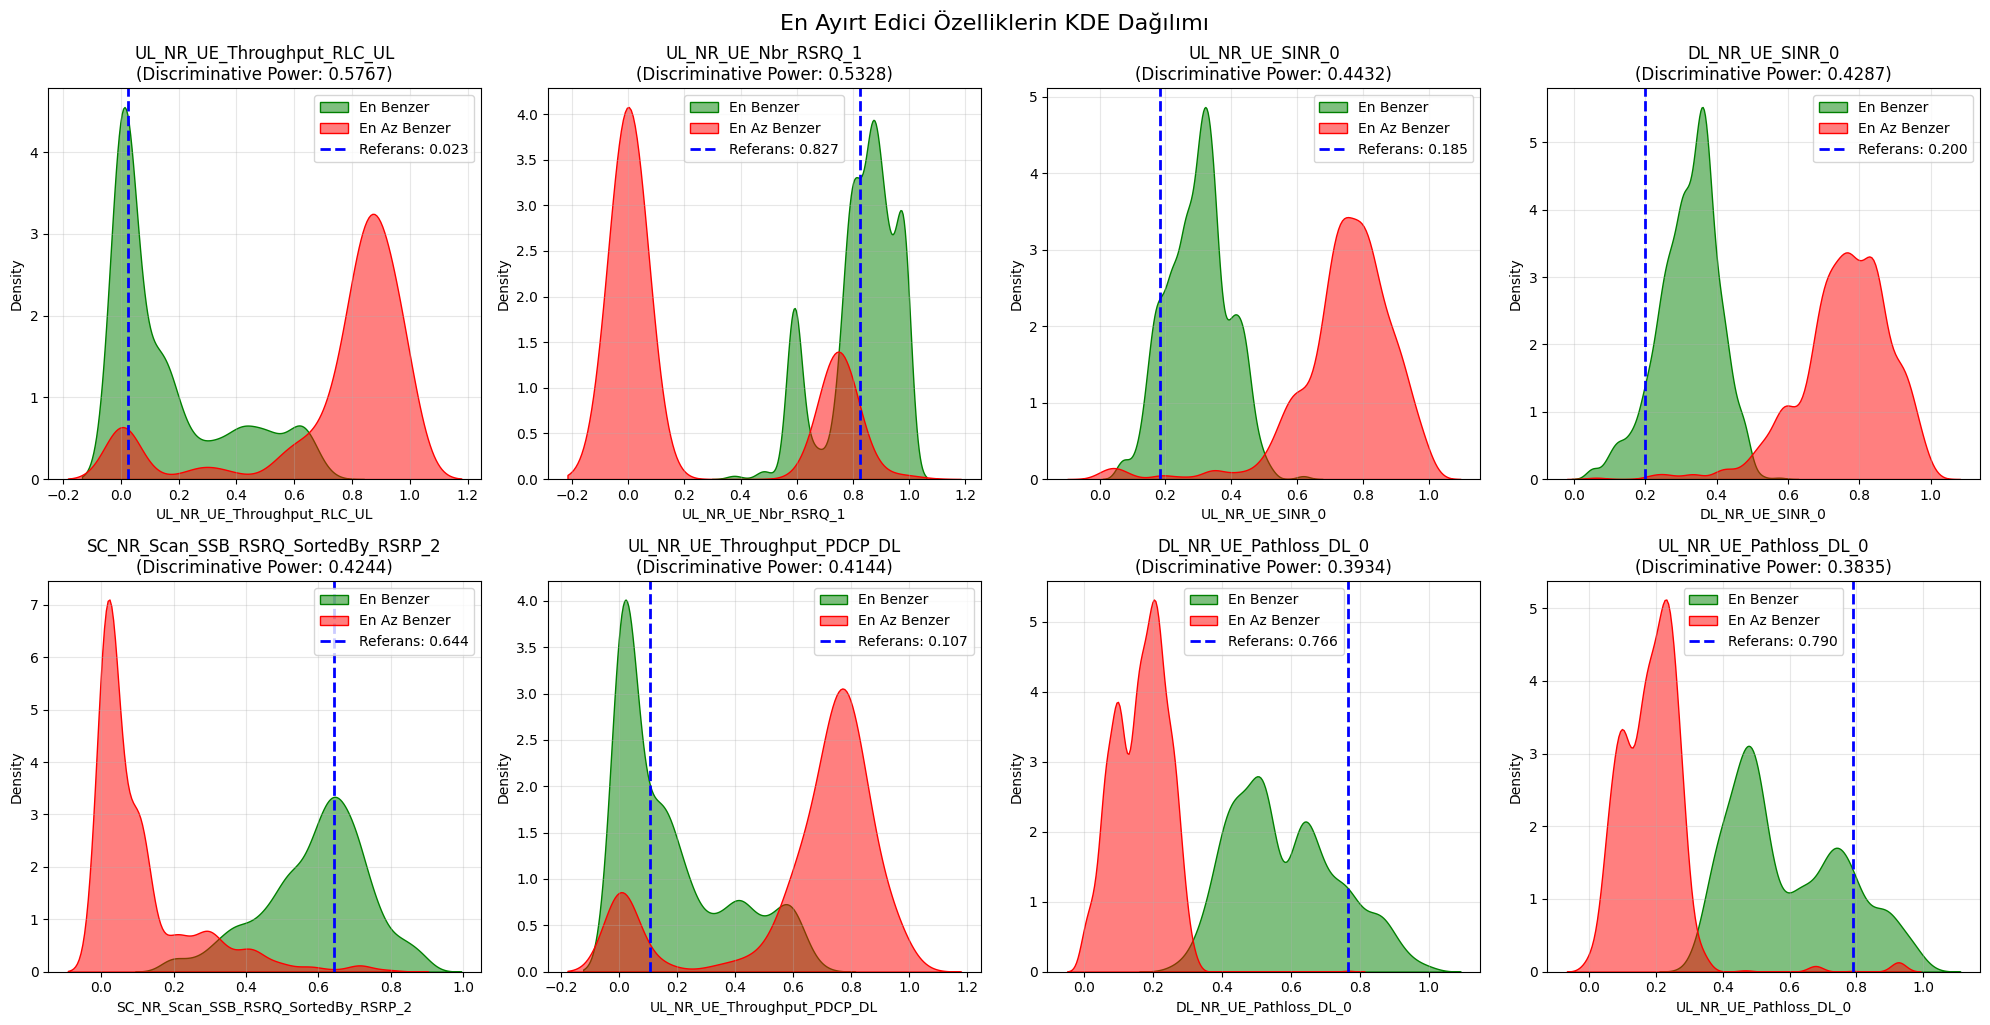

In [18]:
reference_index = random_row_index  # haritada gözüken ref. noktası

# Benzerlik analizi
analysis_result = analyze_similarity_differences(df_numeric, data, reference_index, top_n=30000)

print("====" *30)
# Ayırt edici özellikler
feature_df = feature_importance_analysis(analysis_result)
print("====" *30)
cat_cols, num_cols, cat_but_car = grab_col_names(feature_df)


# Yoğunluk fonksiyonu
print("Grupların olasılık-yoğunluk fonksiyonları (KDE) ile karşılaştırılması")
plot_feature_kde_differences(analysis_result, feature_df[num_cols], top_features=8)

Bu grupların arasında coğrafi olarak önemli bir fark var mı ? 

In [19]:
geographic_analysis(analysis_result, data)


🗺️ COĞRAFİ ANALİZ
En benzer noktaların ortalama mesafesi: 0.003608
En az benzer noktaların ortalama mesafesi: 0.004107
✅ Yakın noktalar daha benzer görünüyor (coğrafi korelasyon var)


İstatistiksel testler

In [20]:
statistical_comparison(analysis_result, feature_df[num_cols])
print("====" *30)


📈 İSTATİSTİKSEL KARŞILAŞTIRMA

🔸 UL_NR_UE_Throughput_RLC_UL:
   En Benzer Grup  - Ortalama: 0.1629, Std: 0.2071
   En Az Benzer Grup - Ortalama: 0.7507, Std: 0.2826
   Ortalama Farkı: 0.5879
   t-testi p-değeri: 0.0000e+00 | Mann-Whitney U p-değeri: 0.0000e+00
   Cohen's d: -2.3731

🔸 UL_NR_UE_Nbr_RSRQ_1:
   En Benzer Grup  - Ortalama: 0.8307, Std: 0.1238
   En Az Benzer Grup - Ortalama: 0.1985, Std: 0.3331
   Ortalama Farkı: 0.6322
   t-testi p-değeri: 0.0000e+00 | Mann-Whitney U p-değeri: 0.0000e+00
   Cohen's d: 2.5159

🔸 UL_NR_UE_SINR_0:
   En Benzer Grup  - Ortalama: 0.2985, Std: 0.0914
   En Az Benzer Grup - Ortalama: 0.7462, Std: 0.1521
   Ortalama Farkı: 0.4477
   t-testi p-değeri: 0.0000e+00 | Mann-Whitney U p-değeri: 0.0000e+00
   Cohen's d: -3.5685

🔸 DL_NR_UE_SINR_0:
   En Benzer Grup  - Ortalama: 0.3209, Std: 0.0838
   En Az Benzer Grup - Ortalama: 0.7583, Std: 0.1271
   Ortalama Farkı: 0.4374
   t-testi p-değeri: 0.0000e+00 | Mann-Whitney U p-değeri: 0.0000e+00
   Cohen'